# Análisis de Métricas de Simplificación de Texto
Este notebook analiza los resultados de la simplificación de texto por diferentes herramientas y modelos, utilizando las métricas SARI, BLEU, BERTScore y los Índices de Legibilidad (Fernández Huerta, Inflesz y Mu).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from metrics.process_data import SummaryColumn 
from metrics.mer_trans_metrics.calculator import MerTrans
from utils import clean_text

c:\Users\prestamo_admin\Documents\01_repo\02_legal_analisys\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prestamo_admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\prestamo_admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [20]:
# Configuración de estilos para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar los datos
df = pd.read_excel('metrics.xlsx', sheet_name='Summary by Document')

# Limpiar los datos: quitar PROMEDIO
df = df[df['document_id'] != 'PROMEDIO'].copy()

# Definir grupos: Normas UNE vs Modelos
une_tools = ['FACILE', 
'SimpleText (ClearText)']
df['Grupo'] = df['document_id'].apply(lambda x: 'Normas UNE' if x in une_tools else 'Modelos IA')

# Seleccionar las métricas clave para el análisis
metricas = [
    SummaryColumn.ORIG_BLEU,
    SummaryColumn.GOLD_BLEU,
    SummaryColumn.ORIG_SARI,
    SummaryColumn.ORIG_BERTSCORE_F1,
    SummaryColumn.GOLD_BERTSCORE_F1,
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.GOLD_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING,
    SummaryColumn.GOLD_ROBERTA_SENSE_FACIL_PRESERVES_MEANING,
    "Cumplimiento"
    ]

print("Datos cargados correctamente. Total de herramientas a analizar:", len(df))


Datos cargados correctamente. Total de herramientas a analizar: 18


In [21]:
DATA_TOTAL_CHECKER = "totales_checkers.xlsx"
df_total_checker = pd.read_excel(DATA_TOTAL_CHECKER)
df_total_checker.rename(columns={"Unnamed: 0": "Tool"}, inplace=True)
df_total_checker

,Tool,Items Cumplidos,Cumplimiento
0,Lectura Fácil [Referencia],15.0,100.000
1,AdaptaTuTexto (deepseek-v3.2)\nSencillo B2,15.0,100.000
2,Asistente de lectura fácil “Antonio Gonzales C...,14.5,96.667
3,SimpleText (ClearText),14.5,96.667
4,FACILE,14.0,93.333
5,GPT 5.4 Think,14.0,93.333
6,AdaptaTuTexto (deepseek-v3.2)\nFacil B1,14.0,93.333
7,deepseek-v3.2,14.0,93.333
8,Claude Sonnet 4.6,14.0,93.333
9,Placea,13.5,90.000


In [22]:
# Join checker totals with main dataframe
df = df.merge(df_total_checker, left_on='document_id', right_on='Tool', how='left')
df.drop(columns=['Tool'], inplace=True)
df[["document_id", "Items Cumplidos", "Cumplimiento"]]

,document_id,Items Cumplidos,Cumplimiento
0,AdaptaTuTexto (Gemini 3.1 Pro)\nFacil B1,12.5,83.333
1,AdaptaTuTexto (Gemini 3.1 Pro)\nMuy A2,11.5,76.667
2,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2,11.0,73.333
3,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2.1,12.0,80.000
4,AdaptaTuTexto (deepseek-v3.2)\nFacil B1,14.0,93.333
5,AdaptaTuTexto (deepseek-v3.2)\nMuy A2,12.5,83.333
6,AdaptaTuTexto (deepseek-v3.2)\nSencillo B2,15.0,100.000
7,"Asistente Lectura Facilitada ""Francisco Javier...",13.5,90.000
8,Asistente de lectura fácil “Antonio Gonzales C...,14.5,96.667
9,Asistente de lectura fácil “Mark Jonathan Cama...,13.5,90.000


## 1. Análisis de Modelos: AdaptaTuTexto
Comparación entre Gemini 3.1 Pro y deepseek-v3.2 en diferentes niveles (Fácil B1, Muy A2, Sencillo B2).

,document_id,LLM,Nivel,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
5,AdaptaTuTexto (deepseek-v3.2)\nMuy A2,deepseek-v3.2,Muy A2,0.1071,0.1213,48.8119,0.7228,0.7602,73.0818,84.1594,0.9910,0.9905,83.333
4,AdaptaTuTexto (deepseek-v3.2)\nFacil B1,deepseek-v3.2,Facil B1,0.1331,0.1059,47.1492,0.7351,0.7500,82.5685,82.1721,0.9837,0.9841,93.333
6,AdaptaTuTexto (deepseek-v3.2)\nSencillo B2,deepseek-v3.2,Sencillo B2,0.2329,0.1051,46.2219,0.8072,0.7665,82.7504,86.2250,0.9821,0.9821,100.000
1,AdaptaTuTexto (Gemini 3.1 Pro)\nMuy A2,Gemini 3.1 Pro,Muy A2,0.0159,0.0499,43.7974,0.6344,0.7114,70.6327,85.8985,0.9908,0.9918,76.667
3,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2.1,Gemini 3.1 Pro,Sencillo B2.1,0.0525,0.0608,43.0488,0.7338,0.7481,84.7406,83.5842,0.9902,0.9904,80.000
0,AdaptaTuTexto (Gemini 3.1 Pro)\nFacil B1,Gemini 3.1 Pro,Facil B1,0.0170,0.0424,42.6044,0.6821,0.7154,83.9046,92.8743,0.9904,0.9903,83.333
2,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2,Gemini 3.1 Pro,Sencillo B2,0.0338,0.0493,41.8832,0.7157,0.7374,85.5171,91.9629,0.9909,0.9906,73.333


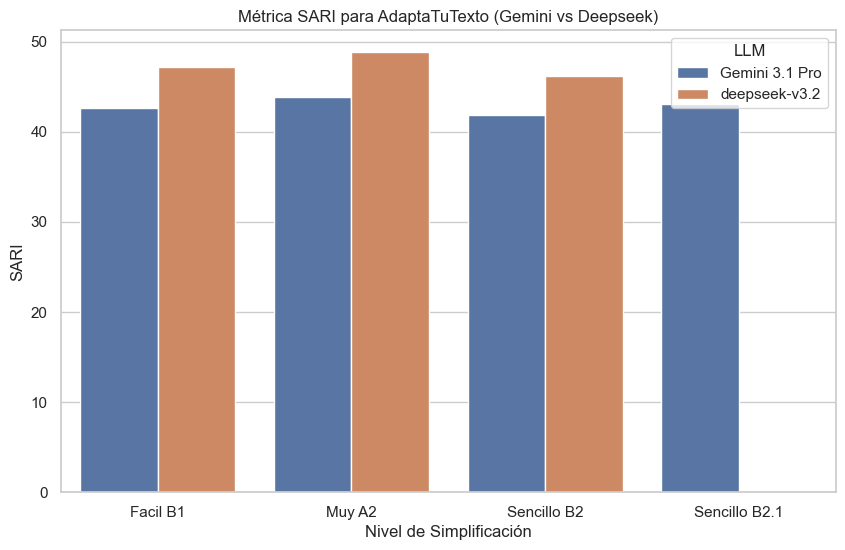

El mejor modelo de AdaptaTuTexto es: AdaptaTuTexto (deepseek-v3.2)
Muy A2


In [19]:
# Filtrar herramientas de AdaptaTuTexto
df_adapta = df[df['document_id'].str.contains('AdaptaTuTexto')].copy()
ORDER_BY = [SummaryColumn.ORIG_SARI, "Cumplimiento"]

# Extraer el LLM y el nivel del nombre
df_adapta['LLM'] = df_adapta['document_id'].apply(lambda x: 'Gemini 3.1 Pro' if 'Gemini' in x else 'deepseek-v3.2')
df_adapta['Nivel'] = df_adapta['document_id'].apply(lambda x: x.split('\n')[1] if '\n' in x else x)

display(df_adapta[['document_id', 'LLM', 'Nivel'] + metricas].sort_values(by=ORDER_BY, ascending=False))

# Gráfica SARI por LLM y Nivel
plt.figure(figsize=(10, 6))
sns.barplot(data=df_adapta, x='Nivel', y=SummaryColumn.ORIG_SARI, hue='LLM')
plt.title('Métrica SARI para AdaptaTuTexto (Gemini vs Deepseek)')
plt.ylabel('SARI')
plt.xlabel('Nivel de Simplificación')
plt.show()

# Seleccionamos el mejor de AdaptaTuTexto (basado en SARI)
mejor_adapta_id = df_adapta.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print("El mejor modelo de AdaptaTuTexto es:", mejor_adapta_id)


## 2. Análisis de Modelos: Asistentes de Lectura Fácil
Comparación entre los dos asistentes personalizados.

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
7,"Asistente Lectura Facilitada ""Francisco Javier...",0.1512,0.1809,50.6440,0.7518,0.7667,86.8476,85.9946,0.9900,0.9898,90.000
9,Asistente de lectura fácil “Mark Jonathan Cama...,0.0653,0.0921,47.2610,0.7203,0.7492,88.8728,92.0436,0.9900,0.9903,90.000
8,Asistente de lectura fácil “Antonio Gonzales C...,0.0594,0.0716,46.7219,0.7464,0.7321,86.0144,88.2561,0.9911,0.9918,96.667


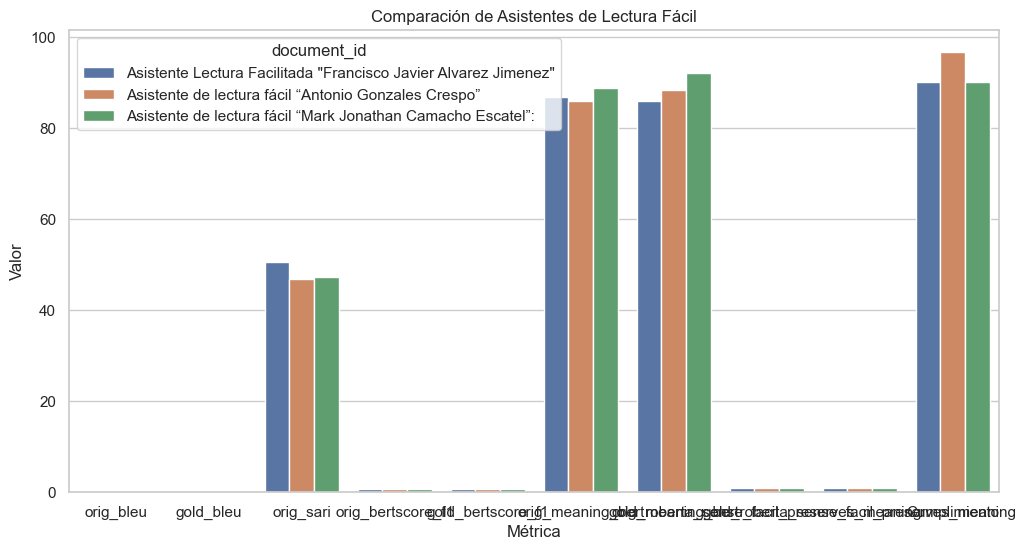

El mejor asistente es: Asistente Lectura Facilitada "Francisco Javier Alvarez Jimenez"


In [21]:
df_asist = df[df['document_id'].str.contains('Asistente')].copy()
display(df_asist[['document_id'] + metricas].sort_values(by=ORDER_BY, ascending=False))

# Gráfica comparativa
df_asist_melt = df_asist.melt(id_vars='document_id', value_vars=metricas, var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_asist_melt, x='Métrica', y='Valor', hue='document_id')
plt.title('Comparación de Asistentes de Lectura Fácil')
plt.show()

mejor_asist_id = df_asist.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print("El mejor asistente es:", mejor_asist_id)


## 3. Análisis de Modelos: Modelos Base
Comparación entre modelos puros (Claude, GPT, Gemini, Deepseek) y Placea.

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
17,deepseek-v3.2,0.1627,0.1857,53.3765,0.7612,0.7856,84.5235,91.0221,0.9895,0.9901,93.333
10,Claude Sonnet 4.6,0.1707,0.1566,50.2891,0.7891,0.7723,82.4910,78.5779,0.9755,0.9724,93.333
12,GPT 5.4 Think,0.1754,0.1673,50.1571,0.8051,0.7702,94.0719,93.8518,0.9875,0.9847,93.333
13,Gemini 3.1 Pro,0.0625,0.1324,49.3049,0.6841,0.7627,79.6245,89.8177,0.9874,0.9897,86.667
15,Placea,0.0867,0.0789,42.1956,0.7563,0.7424,87.9767,90.3143,0.9892,0.9892,90.000


C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_21832\3089177962.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_base, x='document_id', y=SummaryColumn.ORIG_SARI, palette='viridis')


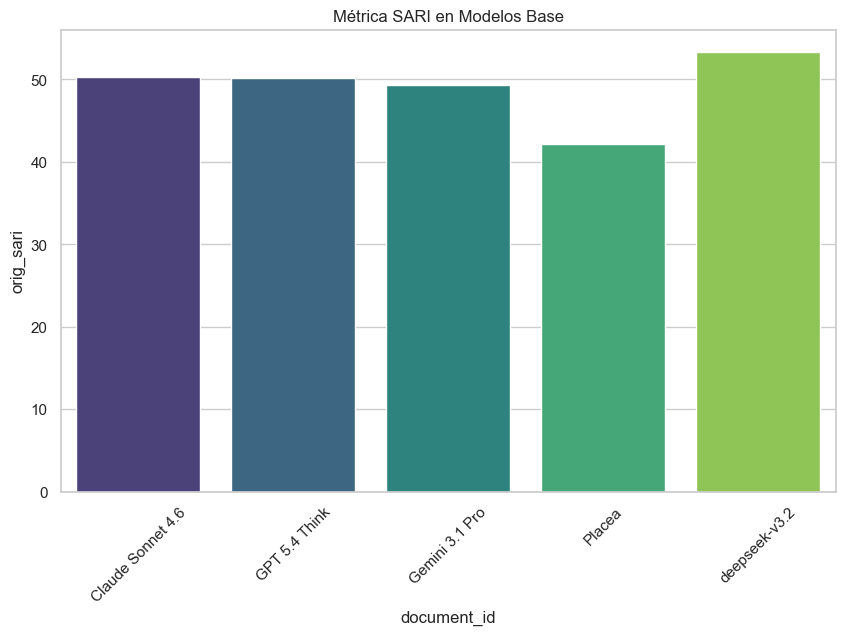

El mejor modelo base es: deepseek-v3.2


In [23]:
modelos_base_nombres = ['Claude Sonnet 4.6', 'GPT 5.4 Think', 'Gemini 3.1 Pro', 'deepseek-v3.2', 'Placea']
df_base = df[df['document_id'].isin(modelos_base_nombres)].copy()
display(df_base[['document_id'] + metricas].sort_values(by=ORDER_BY, ascending=False))

# Gráfica comparativa SARI
plt.figure(figsize=(10, 6))
sns.barplot(data=df_base, x='document_id', y=SummaryColumn.ORIG_SARI, palette='viridis')
plt.title('Métrica SARI en Modelos Base')
plt.xticks(rotation=45)
plt.show()

mejor_base_id = df_base.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print("El mejor modelo base es:", mejor_base_id)


## 4. Comparación de los Mejores Modelos de IA
Comparamos a los ganadores de cada categoría anterior.

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
17,deepseek-v3.2,0.1627,0.1857,53.3765,0.7612,0.7856,84.5235,91.0221,0.9895,0.9901,93.333
7,"Asistente Lectura Facilitada ""Francisco Javier...",0.1512,0.1809,50.6440,0.7518,0.7667,86.8476,85.9946,0.9900,0.9898,90.000
5,AdaptaTuTexto (deepseek-v3.2)\nMuy A2,0.1071,0.1213,48.8119,0.7228,0.7602,73.0818,84.1594,0.9910,0.9905,83.333


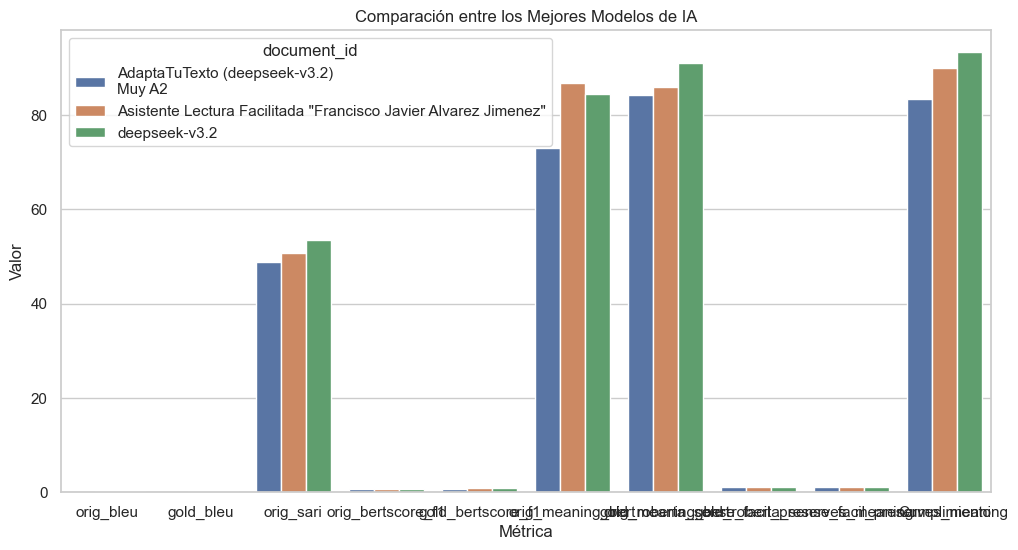

El Mejor Modelo Global de IA es: deepseek-v3.2


In [24]:
mejores_modelos_ids = [mejor_adapta_id, mejor_asist_id, mejor_base_id]
df_mejores_modelos = df[df['document_id'].isin(mejores_modelos_ids)].copy()
display(df_mejores_modelos[['document_id'] + metricas].sort_values(by=ORDER_BY, ascending=False))

df_mejores_melt = df_mejores_modelos.melt(id_vars='document_id', value_vars=metricas, var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_mejores_melt, x='Métrica', y='Valor', hue='document_id')
plt.title('Comparación entre los Mejores Modelos de IA')
plt.show()

el_mejor_modelo_id = df_mejores_modelos.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print("El Mejor Modelo Global de IA es:", el_mejor_modelo_id)


## 5. Comparación Final: Normas UNE vs El Mejor Modelo de IA
Finalmente, comparamos el mejor enfoque basado en LLMs frente a las herramientas tradicionales basadas en normas UNE (FACILE y SimpleText).

,document_id,Grupo,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
17,deepseek-v3.2,Modelos IA,0.1627,0.1857,53.3765,0.7612,0.7856,84.5235,91.0221,0.9895,0.9901,93.333
16,SimpleText (ClearText),Normas UNE,0.8188,0.1701,41.0793,0.9496,0.7208,94.5266,87.5685,0.9798,0.9699,96.667
11,FACILE,Normas UNE,0.7276,0.1619,39.6624,0.9247,0.7262,94.5268,90.8270,0.9648,0.9526,93.333


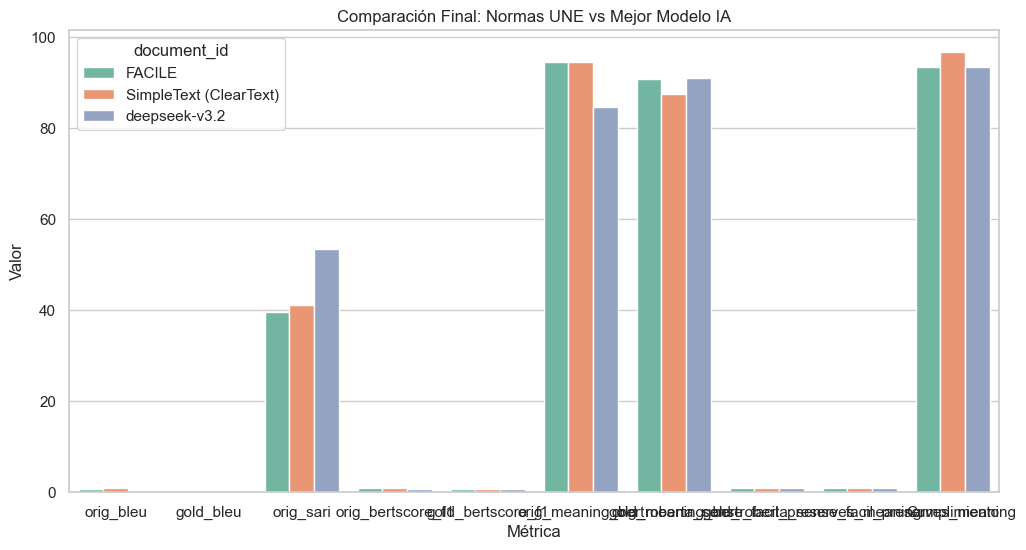

In [25]:
df_final = df[df['document_id'].isin([el_mejor_modelo_id] + une_tools)].copy()
display(df_final[['document_id', 'Grupo'] + metricas].sort_values(by=ORDER_BY, ascending=False))

df_final_melt = df_final.melt(id_vars=['document_id', 'Grupo'], value_vars=metricas, var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_final_melt, x='Métrica', y='Valor', hue='document_id', palette='Set2')
plt.title('Comparación Final: Normas UNE vs Mejor Modelo IA')
plt.show()


## 6. Análisis de Estabilidad y Relación con SARI
En esta sección analizamos qué tan "estables" son las herramientas. La estabilidad se define como la consistencia en el rendimiento a través de todas las métricas. 
Para esto:
1. Normalizamos todas las métricas (escala 0-1).
2. Calculamos la desviación estándar de estas métricas para cada herramienta. Una desviación baja indica mayor estabilidad (equilibrio entre calidad de simplificación, preservación semántica y legibilidad).

Herramientas ordenadas por Estabilidad (Menor Desviación Estándar = Más Estable)


,document_id,orig_sari,estabilidad_std,promedio_norm
6,AdaptaTuTexto (deepseek-v3.2)\nSencillo B2,46.2219,0.204651,0.589508
4,AdaptaTuTexto (deepseek-v3.2)\nFacil B1,47.1492,0.220139,0.498175
12,GPT 5.4 Think,50.1571,0.234983,0.758246
7,"Asistente Lectura Facilitada ""Francisco Javier...",50.6440,0.268210,0.674987
10,Claude Sonnet 4.6,50.2891,0.274223,0.523438
17,deepseek-v3.2,53.3765,0.286663,0.762699
14,Modelo_Qwen3.5_9B,44.6969,0.288518,0.512707
13,Gemini 3.1 Pro,49.3049,0.291180,0.565622
9,Asistente de lectura fácil “Mark Jonathan Cama...,47.2610,0.304947,0.593429
15,Placea,42.1956,0.307082,0.531283


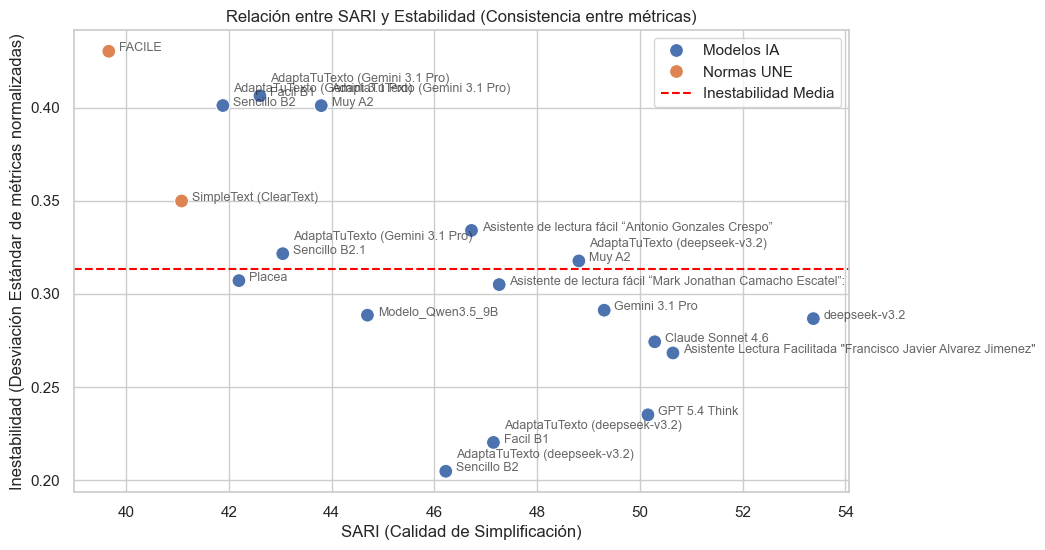

Correlación entre SARI e Inestabilidad: -0.66


In [29]:
# Normalización de métricas
df_m = df[['document_id'] + metricas].set_index('document_id')
df_norm = (df_m - df_m.min()) / (df_m.max() - df_m.min())

# Calcular Estabilidad (desviación estándar de métricas normalizadas)
# Menor desviación = Mayor estabilidad/equilibrio entre métricas
df['estabilidad_std'] = df_norm.std(axis=1).values
df['promedio_norm'] = df_norm.mean(axis=1).values

# Mostrar tabla de estabilidad
print("Herramientas ordenadas por Estabilidad (Menor Desviación Estándar = Más Estable)")
display(df[['document_id', SummaryColumn.ORIG_SARI, 'estabilidad_std', 'promedio_norm']].sort_values(by='estabilidad_std'))

# Gráfica de dispersión: SARI vs Estabilidad
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=SummaryColumn.ORIG_SARI, y='estabilidad_std', hue='Grupo', s=100)
for i in range(df.shape[0]):
    plt.text(df[SummaryColumn.ORIG_SARI].iloc[i]+0.2, df.estabilidad_std.iloc[i], df.document_id.iloc[i], fontsize=9, alpha=0.7)

plt.title('Relación entre SARI y Estabilidad (Consistencia entre métricas)')
plt.xlabel('SARI (Calidad de Simplificación)')
plt.ylabel('Inestabilidad (Desviación Estándar de métricas normalizadas)')
plt.axhline(df['estabilidad_std'].mean(), color='red', linestyle='--', label='Inestabilidad Media')
plt.legend()
plt.show()

# Correlación de Pearson
corr = df[[SummaryColumn.ORIG_SARI, 'estabilidad_std']].corr().iloc[0,1]
print(f"Correlación entre SARI e Inestabilidad: {corr:.2f}")


## Store all data of the metrics calculate

In [31]:
df.to_excel('analisis_herramientas_completo.xlsx', index=False)

# Get Metrics of Gold Reference

In [2]:
df_golf = pd.read_excel("comparacion.xlsx", sheet_name='Matriz comparativa')

In [ ]:
ORIGINAL_FORM = ""
REFERENCE_FORM = ""

for row in df_golf.itertuples():
    if row[2] == "TEXTO ADAPTADO (SALIDA DE CADA HERRAMIENTA DE LF)":
        ORIGINAL_FORM = clean_text(row[3])
        REFERENCE_FORM = clean_text(row[4])

print("Texto Original:", ORIGINAL_FORM[:150])
print("="*50)
print("Texto de Referencia:", REFERENCE_FORM[:150])

Texto Original: AUTORIZACIÓN DE DIFUSIÓN DE IMAGEN/VÍDEO D./Dña. con DNI / Pasaporte nº y con email (a efectos de tratamiento de los datos): , autoriza a la Universid
Texto de Referencia: Permiso para usar mis fotos o vídeos Datos personales Nombre y apellidos: Número de Documento Nacional de Identidad o pasaporte: Correo electrónico: D


In [12]:
cal = MerTrans()
bleu=cal.get_bleu_metric([ORIGINAL_FORM], [REFERENCE_FORM])
bertscore=cal.get_bert_score([ORIGINAL_FORM], [REFERENCE_FORM])
meaning_bert=cal.get_meaning_bert_score([ORIGINAL_FORM], [REFERENCE_FORM])
roberta_sense_facil=cal.get_roberta_sense_facil_metric([ORIGINAL_FORM], [REFERENCE_FORM])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4636.50it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5061.11it/s]


In [45]:
metrics_min =df[[
    SummaryColumn.ORIG_BLEU, 
    SummaryColumn.ORIG_BERTSCORE_F1, 
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING
    ]].min()

metrics_max = df[[
    SummaryColumn.ORIG_BLEU, 
    SummaryColumn.ORIG_BERTSCORE_F1, 
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING
    ]].max()

metrics_mean = df[[
    SummaryColumn.ORIG_BLEU, 
    SummaryColumn.ORIG_BERTSCORE_F1, 
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING
    ]].mean()

In [48]:
df_metrics_gold_summary = pd.DataFrame(
    {
        "Métrica": ["BLEU", "BERTScore F1", "Meaning BERT", "Roberta Sense Facil"],
        "Valor": [bleu.bleu, bertscore.mean_f1, meaning_bert.mean_score, roberta_sense_facil.preserves_meaning],
        "Min": [metrics_min[SummaryColumn.ORIG_BLEU], metrics_min[SummaryColumn.ORIG_BERTSCORE_F1], metrics_min[SummaryColumn.ORIG_MEANING_BERT], metrics_min[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING]],
        "Max": [metrics_max[SummaryColumn.ORIG_BLEU], metrics_max[SummaryColumn.ORIG_BERTSCORE_F1], metrics_max[SummaryColumn.ORIG_MEANING_BERT], metrics_max[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING]],
        "Mean": [metrics_mean[SummaryColumn.ORIG_BLEU], metrics_mean[SummaryColumn.ORIG_BERTSCORE_F1], metrics_mean[SummaryColumn.ORIG_MEANING_BERT], metrics_mean[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING]]
    }

)

In [49]:
df_metrics_gold_summary

,Métrica,Valor,Min,Max,Mean
0,BLEU,0.189666,0.0159,0.8188,0.178150
1,BERTScore F1,0.722042,0.6344,0.9496,0.759517
2,Meaning BERT,74.504333,70.6327,94.5268,85.169022
3,Roberta Sense Facil,0.982493,0.9648,0.9911,0.986311


In [19]:
print(bleu.bleu)
print(bertscore.mean_f1)
print(meaning_bert.mean_score)
print(roberta_sense_facil.preserves_meaning)

0.18966563057752844
0.722042441368103
74.50433349609375
0.9824928045272827


In [18]:
bertscore

BertScoreMetric(precision=[0.7436481714248657], recall=[0.7016567587852478], f1=[0.722042441368103], mean_precision=0.7436481714248657, mean_recall=0.7016567587852478, mean_f1=0.722042441368103)

In [34]:
df[df[SummaryColumn.ORIG_BLEU] >= bleu.bleu][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_BLEU, ascending=False)

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
16,SimpleText (ClearText),0.8188,0.1701,41.0793,0.9496,0.7208,94.5266,87.5685,0.9798,0.9699,96.667
11,FACILE,0.7276,0.1619,39.6624,0.9247,0.7262,94.5268,90.8270,0.9648,0.9526,93.333
6,AdaptaTuTexto (deepseek-v3.2)\nSencillo B2,0.2329,0.1051,46.2219,0.8072,0.7665,82.7504,86.2250,0.9821,0.9821,100.000


In [35]:
df[df[SummaryColumn.ORIG_BERTSCORE_F1] >= bertscore.mean_f1][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_BERTSCORE_F1, ascending=False)

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
16,SimpleText (ClearText),0.8188,0.1701,41.0793,0.9496,0.7208,94.5266,87.5685,0.9798,0.9699,96.667
11,FACILE,0.7276,0.1619,39.6624,0.9247,0.7262,94.5268,90.8270,0.9648,0.9526,93.333
6,AdaptaTuTexto (deepseek-v3.2)\nSencillo B2,0.2329,0.1051,46.2219,0.8072,0.7665,82.7504,86.2250,0.9821,0.9821,100.000
12,GPT 5.4 Think,0.1754,0.1673,50.1571,0.8051,0.7702,94.0719,93.8518,0.9875,0.9847,93.333
10,Claude Sonnet 4.6,0.1707,0.1566,50.2891,0.7891,0.7723,82.4910,78.5779,0.9755,0.9724,93.333
17,deepseek-v3.2,0.1627,0.1857,53.3765,0.7612,0.7856,84.5235,91.0221,0.9895,0.9901,93.333
15,Placea,0.0867,0.0789,42.1956,0.7563,0.7424,87.9767,90.3143,0.9892,0.9892,90.000
7,"Asistente Lectura Facilitada ""Francisco Javier...",0.1512,0.1809,50.6440,0.7518,0.7667,86.8476,85.9946,0.9900,0.9898,90.000
14,Modelo_Qwen3.5_9B,0.1341,0.0814,44.6969,0.7516,0.7441,90.3709,87.8921,0.9897,0.9877,80.000
8,Asistente de lectura fácil “Antonio Gonzales C...,0.0594,0.0716,46.7219,0.7464,0.7321,86.0144,88.2561,0.9911,0.9918,96.667


In [36]:
df[df[SummaryColumn.ORIG_MEANING_BERT] >= meaning_bert.mean_score][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_MEANING_BERT, ascending=False)

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
11,FACILE,0.7276,0.1619,39.6624,0.9247,0.7262,94.5268,90.8270,0.9648,0.9526,93.333
16,SimpleText (ClearText),0.8188,0.1701,41.0793,0.9496,0.7208,94.5266,87.5685,0.9798,0.9699,96.667
12,GPT 5.4 Think,0.1754,0.1673,50.1571,0.8051,0.7702,94.0719,93.8518,0.9875,0.9847,93.333
14,Modelo_Qwen3.5_9B,0.1341,0.0814,44.6969,0.7516,0.7441,90.3709,87.8921,0.9897,0.9877,80.000
9,Asistente de lectura fácil “Mark Jonathan Cama...,0.0653,0.0921,47.2610,0.7203,0.7492,88.8728,92.0436,0.9900,0.9903,90.000
15,Placea,0.0867,0.0789,42.1956,0.7563,0.7424,87.9767,90.3143,0.9892,0.9892,90.000
7,"Asistente Lectura Facilitada ""Francisco Javier...",0.1512,0.1809,50.6440,0.7518,0.7667,86.8476,85.9946,0.9900,0.9898,90.000
8,Asistente de lectura fácil “Antonio Gonzales C...,0.0594,0.0716,46.7219,0.7464,0.7321,86.0144,88.2561,0.9911,0.9918,96.667
2,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2,0.0338,0.0493,41.8832,0.7157,0.7374,85.5171,91.9629,0.9909,0.9906,73.333
3,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2.1,0.0525,0.0608,43.0488,0.7338,0.7481,84.7406,83.5842,0.9902,0.9904,80.000


In [38]:
df[df[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING] >= roberta_sense_facil.preserves_meaning][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING, ascending=False)

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
8,Asistente de lectura fácil “Antonio Gonzales C...,0.0594,0.0716,46.7219,0.7464,0.7321,86.0144,88.2561,0.9911,0.9918,96.667
5,AdaptaTuTexto (deepseek-v3.2)\nMuy A2,0.1071,0.1213,48.8119,0.7228,0.7602,73.0818,84.1594,0.9910,0.9905,83.333
2,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2,0.0338,0.0493,41.8832,0.7157,0.7374,85.5171,91.9629,0.9909,0.9906,73.333
1,AdaptaTuTexto (Gemini 3.1 Pro)\nMuy A2,0.0159,0.0499,43.7974,0.6344,0.7114,70.6327,85.8985,0.9908,0.9918,76.667
0,AdaptaTuTexto (Gemini 3.1 Pro)\nFacil B1,0.0170,0.0424,42.6044,0.6821,0.7154,83.9046,92.8743,0.9904,0.9903,83.333
3,AdaptaTuTexto (Gemini 3.1 Pro)\nSencillo B2.1,0.0525,0.0608,43.0488,0.7338,0.7481,84.7406,83.5842,0.9902,0.9904,80.000
9,Asistente de lectura fácil “Mark Jonathan Cama...,0.0653,0.0921,47.2610,0.7203,0.7492,88.8728,92.0436,0.9900,0.9903,90.000
7,"Asistente Lectura Facilitada ""Francisco Javier...",0.1512,0.1809,50.6440,0.7518,0.7667,86.8476,85.9946,0.9900,0.9898,90.000
14,Modelo_Qwen3.5_9B,0.1341,0.0814,44.6969,0.7516,0.7441,90.3709,87.8921,0.9897,0.9877,80.000
17,deepseek-v3.2,0.1627,0.1857,53.3765,0.7612,0.7856,84.5235,91.0221,0.9895,0.9901,93.333
